# Additional experiments

Run in order. Each stage checkpoints and tees its log to `results/<stem>.log`. Datasets and provenance: `PROVENANCE.md`. Results write-up: `REPORT.md`.

In [1]:
%matplotlib inline

import importlib.metadata as meta
import os, platform, sys

print(f"python        {sys.version.split()[0]}")
print(f"platform      {platform.platform()}")
print(f"cpu count     {os.cpu_count()}")
for name in ("numpy", "scipy", "scikit-learn", "pandas", "lightgbm",
             "featuretools", "openfe", "autofeat", "pmlb", "rdata", "beamfeat"):
    try:
        print(f"{name:<13} {meta.version(name)}")
    except meta.PackageNotFoundError:
        print(f"{name:<13} MISSING")
print(f"interpreter   {sys.executable}")

python        3.11.15
platform      Linux-7.0.0-28-generic-x86_64-with-glibc2.39
cpu count     22
numpy         1.26.4
scipy         1.17.1
scikit-learn  1.7.2
pandas        2.3.3
lightgbm      4.7.0
featuretools  1.31.0
openfe        0.0.12
autofeat      2.1.3
pmlb          1.0.1.post3
rdata         1.1.0
beamfeat      0.3.0
interpreter   <env>/bin/python


In [2]:
# datasets from canonical sources (network access required)
!python fetch_data.py --all

== communities ==
  fetching https://archive.ics.uci.edu/ml/machine-learning-databases/communities/communities.data
  checksum communities_crime_numeric.csv: OK
== superconduct ==
  fetching https://archive.ics.uci.edu/ml/machine-learning-databases/00464/superconduct.zip
  checksum superconductivity.csv: MISMATCH (recorded d20a399d3ce3026f205e15ecc7301531, got ae79c46378c122f782e502628f865f73)
== tecator ==
  fetching https://raw.githubusercontent.com/gogorazet/tecator/main/csvtecator_simplified_header.csv
  checksum tecator.csv: OK
== eyedata ==
  fetching https://codeload.github.com/cran/flare/tar.gz/refs/heads/master
  checksum eyedata.csv: OK
== riboflavin ==
  fetching https://codeload.github.com/cran/hdi/tar.gz/refs/heads/master
  checksum riboflavin.csv: OK
== ct_slices ==
  fetching https://archive.ics.uci.edu/ml/machine-learning-databases/00206/slice_localization_data.zip
  checksum ct_slices.csv: 1f89191fa765d2c54b0c3c055cc46819 (new; append to CHECKSUMS.md5)
== blogfeedback 

## Datasets

In [3]:
import pathlib
import numpy as np, pandas as pd

DATA = pathlib.Path("data")
SPECS = [
    ("communities",   "communities_crime_numeric.csv", "last",         "violent-crime rate"),
    ("superconduct",  "superconductivity.csv",         "critical_temp","critical temperature (K)"),
    ("tecator",       "tecator.csv",                   "fat",          "fat content (%)"),
    ("eyedata",       "eyedata.csv",                   "trim32",       "TRIM32 expression"),
    ("riboflavin",    "riboflavin.csv",                "first",        "log production rate"),
    ("ct_slices",     "ct_slices.csv",                 "last",         "axial slice position"),
    ("blogfeedback",  "blogfeedback.csv",              "last",         "comment count"),
    ("ujiindoorloc",  "ujiindoorloc.csv",              "longitude",    "longitude (m)"),
    ("geomusic",      "geomusic.csv",                  "last",         "latitude of origin"),
]

def load(path, target):
    df = pd.read_csv(path)
    if target == "last":  y = df.iloc[:, -1]; X = df.iloc[:, :-1]
    elif target == "first": y = df.iloc[:, 0]; X = df.iloc[:, 1:]
    else: y = df[target]; X = df.drop(columns=target)
    if path.name == "tecator.csv":
        X = X[[c for c in X.columns if c.startswith(("_", "absorbance"))]]
    return X, y

rows, shapes = [], {}
for name, fname, target, desc in SPECS:
    p = DATA / fname
    if not p.exists():
        rows.append((name, "-", "-", desc, "absent (fetch_data.py --all)")); continue
    X, y = load(p, target)
    shapes[name] = (len(X), X.shape[1])
    rows.append((name, len(X), X.shape[1], desc,
                 f"target {y.min():.3g} to {y.max():.3g}"))
overview = pd.DataFrame(rows, columns=["dataset", "n", "p", "target", "range / status"])
overview

,dataset,n,p,target,range / status
0,communities,1993,100,violent-crime rate,target 0 to 1
1,superconduct,21263,81,critical temperature (K),target 0.00021 to 185
2,tecator,240,100,fat content (%),target 0.9 to 58.5
3,eyedata,120,200,TRIM32 expression,target 7.38 to 8.75
4,riboflavin,71,4088,log production rate,target -9.97 to -5.67
5,ct_slices,53500,384,axial slice position,target 1.74 to 97.5
6,blogfeedback,52397,280,comment count,target 0 to 1.42e+03
7,ujiindoorloc,19937,520,longitude (m),target -7.69e+03 to -7.3e+03
8,geomusic,1059,117,latitude of origin,target -1.51 to 5.85


In [4]:
def probe(X, y, max_rows=3000, max_cols=300, seed=0):
    """Sub-sample rows and columns for the pairwise statistics."""
    rng = np.random.default_rng(seed)
    ri = rng.choice(len(X), min(len(X), max_rows), replace=False)
    ci = rng.choice(X.shape[1], min(X.shape[1], max_cols), replace=False)
    A = X.to_numpy(float)[np.ix_(ri, ci)]
    return A[:, A.std(axis=0) > 0], y.to_numpy(float)[ri]

rows, cache = [], {}
for name, fname, target, desc in SPECS:
    path = DATA / fname
    if not path.exists():
        rows.append(dict(dataset=name, status="absent")); continue
    X, y = load(path, target)
    A, yy = probe(X, y)
    with np.errstate(all="ignore"):
        C = np.corrcoef(A, rowvar=False)
        off = np.abs(C[np.triu_indices_from(C, k=1)]); off = off[np.isfinite(off)]
        Az = (A - A.mean(0)) / A.std(0)
        yz = (yy - yy.mean()) / (yy.std() or 1.0)
        marginal = np.abs(Az.T @ yz) / len(yy)
    cache[name] = (A, yy, off, marginal)
    rows.append(dict(dataset=name, n=len(X), p=X.shape[1],
                     missing=int(X.isna().sum().sum()),
                     constant=int((X.nunique() <= 1).sum()),
                     dup_rows=int(X.duplicated().sum()),
                     target_skew=round(float(pd.Series(y).skew()), 2),
                     med_absr=round(float(np.median(off)), 3),
                     p95_absr=round(float(np.quantile(off, 0.95)), 3),
                     max_absr=round(float(off.max()), 4),
                     med_marginal=round(float(np.median(marginal)), 3)))
diagnostics = pd.DataFrame(rows)
diagnostics

,dataset,n,p,missing,constant,dup_rows,target_skew,med_absr,p95_absr,max_absr,med_marginal
0,communities,1993,100,0,0,0,1.52,0.195,0.689,0.9955,0.278
1,superconduct,21263,81,0,0,6093,0.86,0.307,0.793,0.9975,0.377
2,tecator,240,100,0,0,24,1.00,0.986,1.000,1.0000,0.420
3,eyedata,120,200,0,0,0,-2.85,0.613,0.788,0.9257,0.614
4,riboflavin,71,4088,0,0,0,-0.84,0.287,0.681,0.9906,0.113
5,ct_slices,53500,384,0,5,64,0.31,0.105,0.480,1.0000,0.174
6,blogfeedback,52397,280,0,4,3603,12.69,0.043,0.667,1.0000,0.010
7,ujiindoorloc,19937,520,0,55,852,-0.41,0.016,0.176,1.0000,0.086
8,geomusic,1059,117,0,0,0,1.70,0.140,0.914,1.0000,0.056


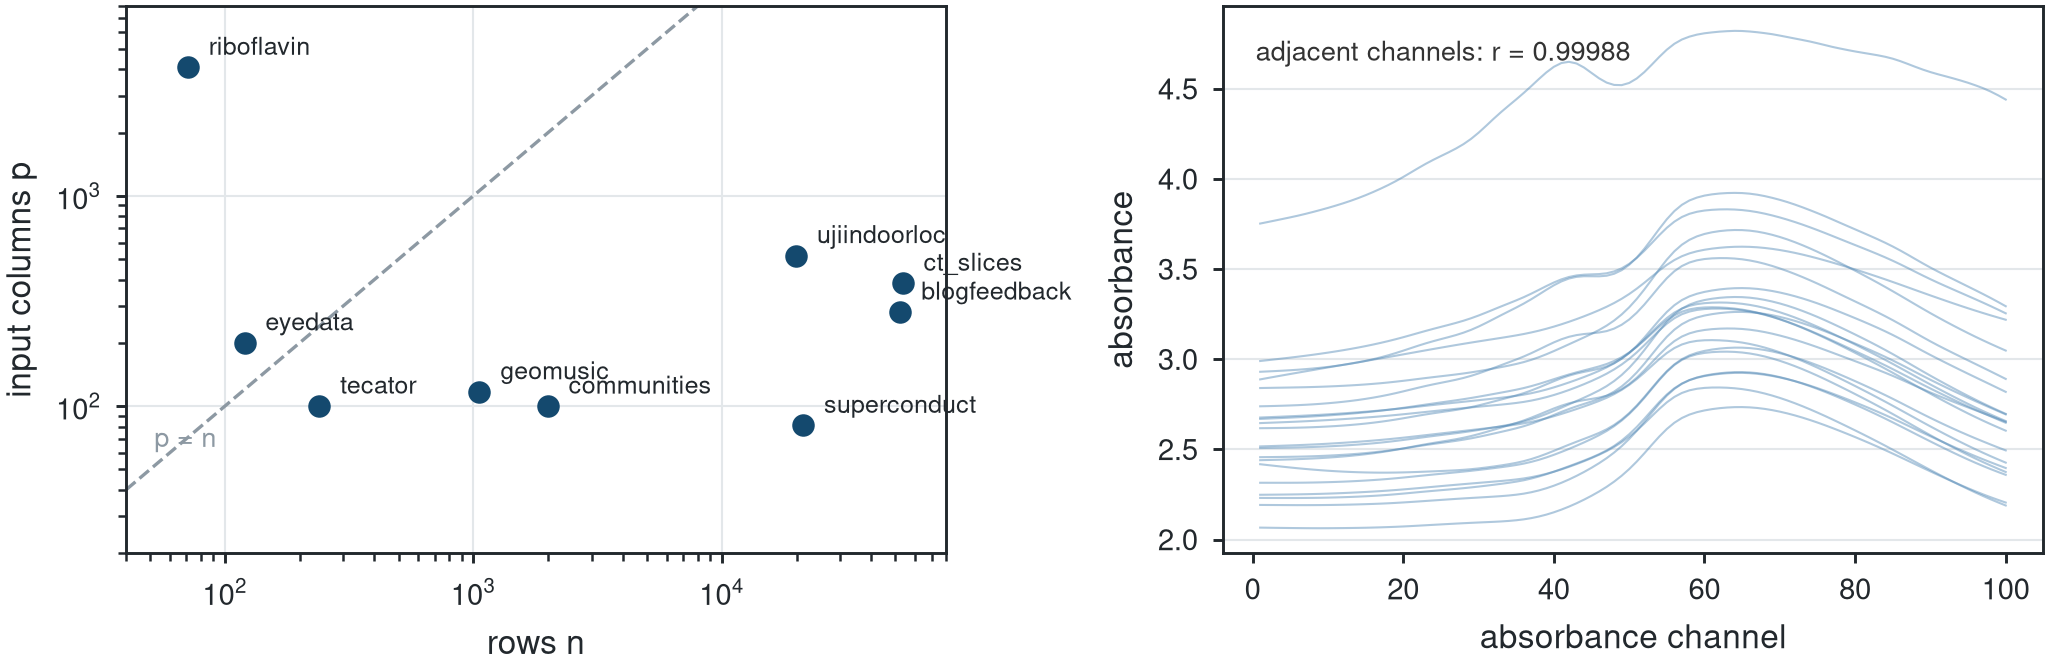

In [5]:
import matplotlib.pyplot as plt
from make_figures import (use_acs_style, ACCENT, ACCENT_LT, WARN, NEUTRAL,
                          GRID, COL_DOUBLE)

use_acs_style()
fig, axes = plt.subplots(1, 2, figsize=(COL_DOUBLE, 2.4))

ax = axes[0]                                   # where each dataset sits in (n, p)
for name, (n, p) in shapes.items():
    ax.scatter(n, p, s=24, color=ACCENT, zorder=3)
    ax.annotate(name, (n, p), textcoords="offset points", xytext=(5, 3), fontsize=6)
lim = [40, 80_000]
ax.plot(lim, lim, linestyle="--", linewidth=0.8, color=NEUTRAL)
ax.annotate("p = n", (lim[0] * 1.3, lim[0] * 1.6), fontsize=6.5, color=NEUTRAL)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(lim); ax.set_ylim(20, 8000)
ax.set_xlabel("rows n"); ax.set_ylabel("input columns p")
ax.grid(True, axis="both", color=GRID, linewidth=0.5)

ax = axes[1]                                   # tecator: adjacent absorbance channels
tp = DATA / "tecator.csv"
if tp.exists():
    X, _ = load(tp, "fat")
    A = X.to_numpy(float)
    for row in A[::12]:
        ax.plot(range(1, 101), row, linewidth=0.5, color=ACCENT_LT, alpha=0.45)
    r = np.corrcoef(A[:, 49], A[:, 50])[0, 1]
    ax.annotate(f"adjacent channels: r = {r:.5f}", (0.04, 0.9),
                xycoords="axes fraction", fontsize=6.5, color="#333333")
    ax.set_xlabel("absorbance channel"); ax.set_ylabel("absorbance")
    ax.grid(True, axis="y", color=GRID, linewidth=0.5)
else:
    ax.axis("off")
pathlib.Path("figures").mkdir(exist_ok=True)
fig.tight_layout()
fig.savefig("figures/datasets_overview.pdf"); fig.savefig("figures/datasets_overview.png", dpi=300)
plt.show()

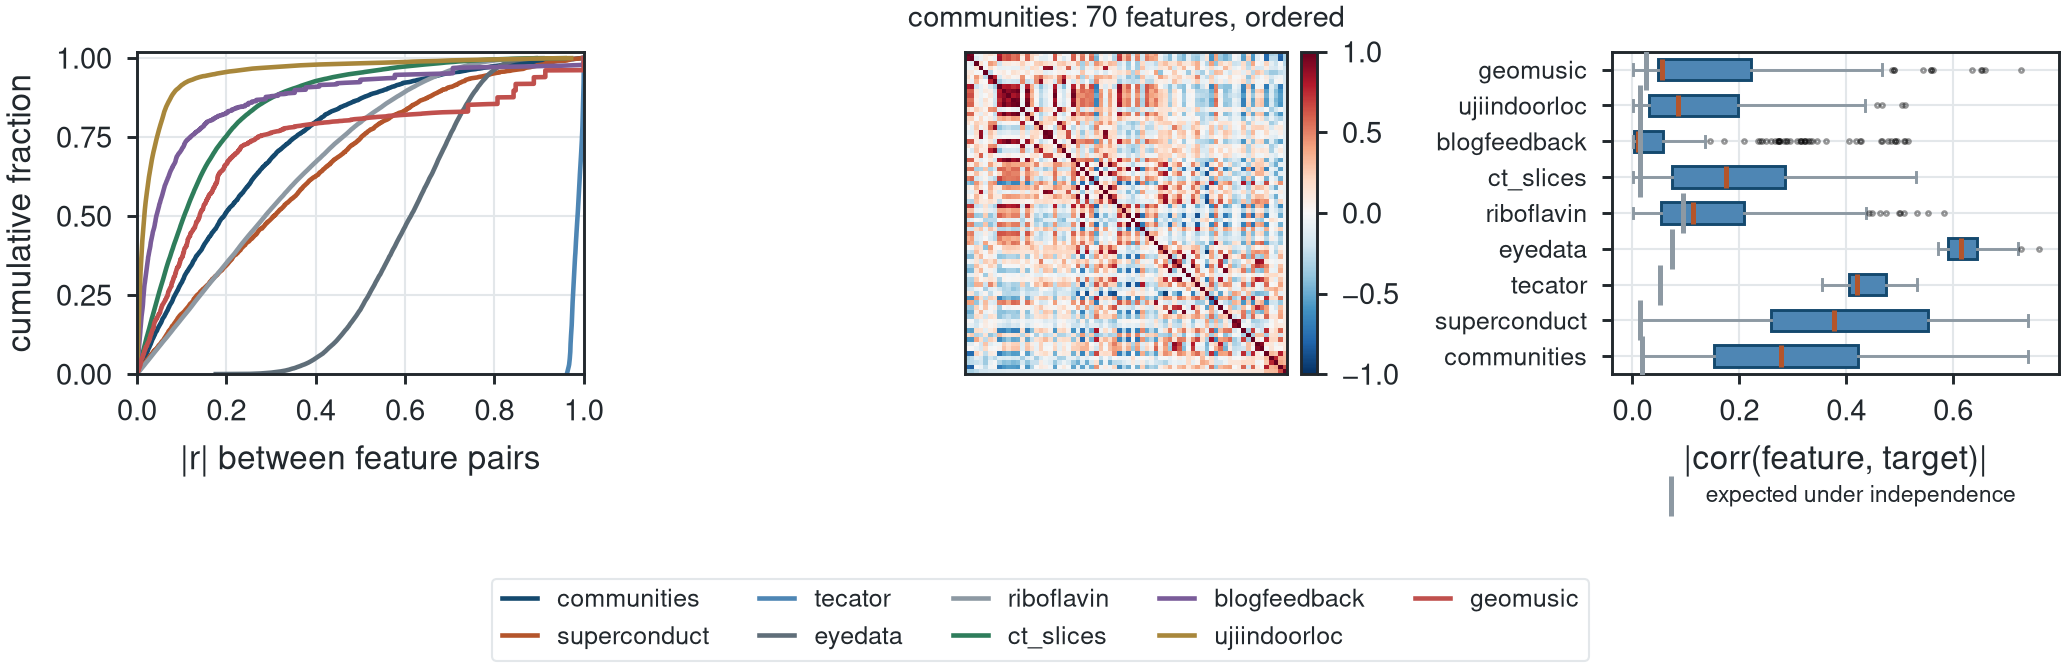

In [6]:
present = list(cache)
SERIES = ["#14496E", "#B4552B", "#4E86B4", "#5F6E79", "#8D99A3",
          "#2E7D5B", "#7A5C99", "#A8873B", "#C0504D"]

fig, axes = plt.subplots(1, 3, figsize=(COL_DOUBLE, 2.2))

ax = axes[0]                                    # dependence among candidates
for i, name in enumerate(present):
    xs = np.sort(cache[name][2]); ys = np.arange(1, len(xs) + 1) / len(xs)
    step = max(1, len(xs) // 1500)
    ax.plot(xs[::step], ys[::step], linewidth=1.1, color=SERIES[i % len(SERIES)], label=name)
ax.set_xlabel("|r| between feature pairs"); ax.set_ylabel("cumulative fraction")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.grid(True, axis="both", color=GRID, linewidth=0.5)

ax = axes[1]                                    # a correlation matrix with visible structure
pick = "communities" if "communities" in cache else present[0]
A = cache[pick][0][:, :70]
order = np.argsort(np.corrcoef(A, rowvar=False)[0])
im = ax.imshow(np.corrcoef(A[:, order], rowvar=False), cmap="RdBu_r",
               vmin=-1, vmax=1, interpolation="nearest")
ax.set_title(f"{pick}: 70 features, ordered", fontsize=7)
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

ax = axes[2]                                    # marginal association with the target
box_kw = dict(widths=0.6, patch_artist=True,
              flierprops=dict(marker=".", markersize=1.2, alpha=0.4))
try:                                            # matplotlib >= 3.10
    bp = ax.boxplot([cache[n][3] for n in present], orientation="horizontal", **box_kw)
except TypeError:                               # older releases
    bp = ax.boxplot([cache[n][3] for n in present], vert=False, **box_kw)
ax.set_yticks(range(1, len(present) + 1), present)
for patch in bp["boxes"]:
    patch.set_facecolor(ACCENT_LT); patch.set_edgecolor(ACCENT); patch.set_linewidth(0.7)
for med in bp["medians"]: med.set_color(WARN); med.set_linewidth(1.2)
for w in bp["whiskers"] + bp["caps"]: w.set_color(NEUTRAL); w.set_linewidth(0.7)
# |r| is n-dependent, so mark what independence alone would produce:
# E|r| = sqrt(2 / (pi (n - 1))) for each dataset's probe sample
null_level = [np.sqrt(2 / (np.pi * (cache[n][0].shape[0] - 1))) for n in present]
ax.scatter(null_level, range(1, len(present) + 1), marker="|", s=90,
           color=NEUTRAL, zorder=4, label="expected under independence")
ax.legend(fontsize=5.5, loc="upper center", bbox_to_anchor=(0.5, -0.28),
          frameon=False)
ax.set_xlabel("|corr(feature, target)|"); ax.tick_params(axis="y", labelsize=6)
ax.grid(True, axis="x", color=GRID, linewidth=0.5)

handles, labels = axes[0].get_legend_handles_labels()   # one legend under all panels
fig.legend(handles, labels, loc="lower center", ncols=min(5, len(labels)),
           fontsize=6, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=(0, 0.10, 1, 1))
fig.savefig("figures/diagnostics_dependence.pdf"); fig.savefig("figures/diagnostics_dependence.png", dpi=300)
plt.show()

## Comparison on high-dimensional data

The baselines and beamfeat over nine datasets, p = 81 to 4,088, at a 900 s per-fit budget.

In [7]:
!python bench.py highdim ridge_raw,rf_raw,lgbm_raw,beamfeat,beamfeat_ridge 5 results/highdim_fast.json 2>&1 | tee results/highdim_fast.log | grep --line-buffered -E 'R2=|ERROR|Traceback|wrote'

communities_p100 ridge_raw     s0 R2=+0.6654     1.6s n_new=None
communities_p100 rf_raw        s0 R2=+0.6597     3.2s n_new=None
communities_p100 lgbm_raw      s0 R2=+0.6614     3.2s n_new=None
communities_p100 beamfeat      s0 R2=+0.6562     9.4s n_new=10
communities_p100 beamfeat_ridge s0 R2=+0.6563     9.4s n_new=10
communities_p100 ridge_raw     s1 R2=+0.5970     1.6s n_new=None
communities_p100 rf_raw        s1 R2=+0.5965     3.4s n_new=None
communities_p100 lgbm_raw      s1 R2=+0.5695     3.1s n_new=None
communities_p100 beamfeat      s1 R2=+0.6064     9.4s n_new=10
communities_p100 beamfeat_ridge s1 R2=+0.6061     9.5s n_new=10
communities_p100 ridge_raw     s2 R2=+0.6742     1.5s n_new=None
communities_p100 rf_raw        s2 R2=+0.6600     3.4s n_new=None
communities_p100 lgbm_raw      s2 R2=+0.6509     3.2s n_new=None
communities_p100 beamfeat      s2 R2=+0.6480     9.6s n_new=9
communities_p100 beamfeat_ridge s2 R2=+0.6477     9.6s n_new=9
communities_p100 ridge_raw     s3 R2

In [8]:
# Label-permuted controls at p = 4,088: the selector must return nothing.
from beamfeat import BeamFeatTransformer

path = pathlib.Path("data/riboflavin.csv")
if path.exists():
    df = pd.read_csv(path)
    X, y = df.iloc[:, 1:].to_numpy(float), df.iloc[:, 0].to_numpy(float)
    rng = np.random.default_rng(0)
    counts = []
    for s in range(5):
        m = BeamFeatTransformer(random_state=s).fit(X, rng.permutation(y))
        counts.append(len(m.formulas()))
        print(f"permuted control {s}: selected {counts[-1]}")
    print(f"controls selecting nothing: {sum(c == 0 for c in counts)}/5")
else:
    print("riboflavin.csv absent; run fetch_data.py first")

permuted control 0: selected 0
permuted control 1: selected 0
permuted control 2: selected 0
permuted control 3: selected 0
permuted control 4: selected 0
controls selecting nothing: 5/5


## What the certified features carry

The comparison hands every constructor's output to the same linear model, so
that differences reflect the features rather than the consumer. That leaves
one question unasked: whether the certified features hold structure a tree
ensemble cannot extract for itself, and whether a shortfall against the tree
baselines is a property of the features or of the consumer they are given to.

The grid below is fixed, not searched: the same three consumers on every
dataset, on the raw columns and on the certified features. The highest cell
in a row is not a result: choosing a consumer by test score is selection on
the test set, and the reported method keeps ridge, whose coefficients are the
deliverable. What the grid is for is the direction of the gap. Where the
certified features close most of the distance to the tree baselines, the
shortfall was the consumer; where they do not, it was the screening, and the
signal is too diffuse for a sparsity-oriented guarantee to keep.

The rows, caps and splits come from the comparison harness itself, so the
raw columns here reproduce its baseline numbers.

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from beamfeat import BeamFeatTransformer

from bench import get_datasets      # identical rows, caps and seeds as the comparison

# every dataset in the comparison, cheapest first so an interrupted run
# still leaves a usable table
CASES = ["tecator_p100", "communities_p100", "superconduct_p81", "geomusic_p117",
         "eyedata_p200", "riboflavin_p4088", "blogfeedback_p280", "ct_slices_p384",
         "ujiindoorloc_p520"]
SPLITS = 3
POOL = get_datasets("highdim")

def consumers(A, ytr, B, yte):
    return {
        "ridge": make_pipeline(StandardScaler(),
                               RidgeCV(alphas=np.logspace(-4, 4, 25))).fit(A, ytr).score(B, yte),
        "rf": RandomForestRegressor(n_estimators=300, random_state=0,
                                    n_jobs=-1).fit(A, ytr).score(B, yte),
        "lgbm": lgb.LGBMRegressor(n_estimators=300, random_state=0,
                                  verbose=-1).fit(A, ytr).score(B, yte),
    }

rows = []
for name in CASES:
    if name not in POOL:
        print(f"{name:18s} skipped, not fetched", flush=True)
        continue
    Xd, yd, _ = POOL[name]
    for split in range(SPLITS):
        Xtr, Xte, ytr, yte = train_test_split(Xd, yd, test_size=0.25, random_state=split)
        raw = consumers(Xtr, ytr, Xte, yte)
        tf = BeamFeatTransformer(random_state=0).fit(Xtr, ytr)
        con = consumers(tf.transform(Xtr), ytr, tf.transform(Xte), yte)
        rows.append(dict(dataset=name, split=split, k=len(tf.formulas()),
                         **{f"raw_{a}": b for a, b in raw.items()},
                         **{f"bf_{a}": b for a, b in con.items()}))
        print(f"{name:18s} s{split}  k={len(tf.formulas()):3d}  "
              f"raw {raw['ridge']:.3f}/{raw['rf']:.3f}/{raw['lgbm']:.3f}  "
              f"bf {con['ridge']:.3f}/{con['rf']:.3f}/{con['lgbm']:.3f}", flush=True)

    pd.DataFrame(rows).to_json("results/consumer_ablation_rows.json")   # checkpoint per dataset

consumer_table = (pd.DataFrame(rows).drop(columns="split")
                  .groupby("dataset").mean().round(3).reindex(
                      [n for n in CASES if n in set(r["dataset"] for r in rows)]))
consumer_table["tree_gap_raw"] = (consumer_table[["raw_rf", "raw_lgbm"]].max(axis=1)
                                  - consumer_table["raw_ridge"]).round(3)
consumer_table["gap_closed"] = (consumer_table[["bf_rf", "bf_lgbm"]].max(axis=1)
                                - consumer_table["bf_ridge"]).round(3)
consumer_table.to_json("results/consumer_ablation.json")
consumer_table

tecator_p100       s0  k=  4  raw 0.946/0.682/0.739  bf 0.990/0.990/0.969
tecator_p100       s1  k=  4  raw 0.963/0.789/0.791  bf 0.992/0.993/0.969
tecator_p100       s2  k=  3  raw 0.952/0.746/0.858  bf 0.990/0.993/0.978
communities_p100   s0  k= 10  raw 0.665/0.660/0.661  bf 0.656/0.633/0.592
communities_p100   s1  k= 10  raw 0.597/0.597/0.569  bf 0.606/0.571/0.525
communities_p100   s2  k=  9  raw 0.674/0.660/0.651  bf 0.648/0.638/0.566
superconduct_p81   s0  k= 12  raw 0.725/0.883/0.883  bf 0.715/0.859/0.861
superconduct_p81   s1  k= 10  raw 0.739/0.894/0.894  bf 0.729/0.876/0.873
superconduct_p81   s2  k= 16  raw 0.714/0.881/0.878  bf 0.732/0.854/0.849
geomusic_p117      s0  k=  8  raw 0.805/0.723/0.706  bf 0.787/0.823/0.767
geomusic_p117      s1  k= 10  raw 0.775/0.751/0.736  bf 0.789/0.800/0.765
geomusic_p117      s2  k= 11  raw 0.818/0.757/0.783  bf 0.813/0.824/0.765
eyedata_p200       s0  k= 42  raw 0.441/0.452/-0.060  bf 0.367/0.359/-0.041
eyedata_p200       s1  k= 39  raw 0.

,k,raw_ridge,raw_rf,raw_lgbm,bf_ridge,bf_rf,bf_lgbm,tree_gap_raw,gap_closed
dataset,,,,,,,,,
tecator_p100,3.667,0.954,0.739,0.796,0.991,0.992,0.972,-0.158,0.001
communities_p100,9.667,0.646,0.639,0.627,0.637,0.614,0.561,-0.007,-0.023
superconduct_p81,12.667,0.726,0.886,0.885,0.726,0.863,0.861,0.160,0.137
geomusic_p117,9.667,0.800,0.744,0.742,0.796,0.816,0.765,-0.056,0.020
eyedata_p200,35.333,0.559,0.406,0.063,0.504,0.383,-0.031,-0.153,-0.121
riboflavin_p4088,17.000,0.642,0.440,0.555,0.648,0.590,0.525,-0.087,-0.058
blogfeedback_p280,15.667,0.351,0.509,0.493,0.343,0.421,0.398,0.158,0.078
ct_slices_p384,13.667,0.852,0.982,0.982,0.677,0.858,0.864,0.130,0.187
ujiindoorloc_p520,20.000,0.950,0.995,0.994,0.813,0.928,0.926,0.045,0.115


## Search depth and robustness

Recovery of planted targets across depth, scorer and beam width, including targets whose intermediates carry zero population correlation with the target.

In [10]:
!python depth_ladder.py --seeds 10 --out results/depth_ladder.json 2>&1 | tee results/depth_ladder.log

d1_product         scorer=correlation  beam= 20 recovered_all=1.00
d1_product         scorer=correlation  beam= 50 recovered_all=1.00
d1_product         scorer=correlation  beam=100 recovered_all=1.00
d1_product         scorer=correlation  beam=200 recovered_all=1.00
d1_product         scorer=mutual_info  beam= 20 recovered_all=1.00
d1_product         scorer=mutual_info  beam= 50 recovered_all=1.00
d1_product         scorer=mutual_info  beam=100 recovered_all=1.00
d1_product         scorer=mutual_info  beam=200 recovered_all=1.00
d1_ratio           scorer=correlation  beam= 20 recovered_all=1.00
d1_ratio           scorer=correlation  beam= 50 recovered_all=1.00
d1_ratio           scorer=correlation  beam=100 recovered_all=1.00
d1_ratio           scorer=correlation  beam=200 recovered_all=1.00
d1_ratio           scorer=mutual_info  beam= 20 recovered_all=0.90
d1_ratio           scorer=mutual_info  beam= 50 recovered_all=0.90
d1_ratio           scorer=mutual_info  beam=100 recovered_all=

## Selection procedures

BH, BY, fixed-X and model-X knockoffs across four dependence regimes, reporting realised FDR under both null definitions.

In [11]:
!python selector_comparison.py --trials 100 --out results/selector_comparison.json 2>&1 | tee results/selector_comparison.log
!python selector_comparison.py --trials 100 --m 100 --k 10 --out results/selector_comparison_m100.json 2>&1 | tee results/selector_comparison_m100.log

independent       bh               q=0.05 FDRm=0.065 FDRc=0.065 power=1.000 skipped=0
independent       by               q=0.05 FDRm=0.015 FDRc=0.015 power=1.000 skipped=0
[beamfeat.selection] knockoff+ (offset=1) selected nothing at target FDR 0.05, but offset=0 — which controls only a modified FDR — would have selected 7 feature(s). If that trade-off is acceptable, pass KnockoffSelector(offset=0) as the selector; the permutation selector is the recommended default for engineered candidates
[beamfeat.selection] knockoff+ (offset=1) selected nothing at target FDR 0.05, but offset=0 — which controls only a modified FDR — would have selected 7 feature(s). If that trade-off is acceptable, pass KnockoffSelector(offset=0) as the selector; the permutation selector is the recommended default for engineered candidates
[beamfeat.selection] knockoff+ (offset=1) selected nothing at target FDR 0.05, but offset=0 — which controls only a modified FDR — would have selected 6 feature(s). If that trade

## Split stability

Thirty independent search/selection splits per dataset, selections compared up to value-equivalence, plus the multi-split aggregate.

In [12]:
!python split_stability.py --splits 30 --out results/split_stability.json 2>&1 | tee results/split_stability.log

three_way      split  0 R2=+1.000 n=1
three_way      split  1 R2=+1.000 n=1
three_way      split  2 R2=+1.000 n=1
three_way      split  3 R2=+1.000 n=1
three_way      split  4 R2=+1.000 n=1
three_way      split  5 R2=+1.000 n=1
three_way      split  6 R2=+1.000 n=1
three_way      split  7 R2=+1.000 n=1
three_way      split  8 R2=+1.000 n=1
three_way      split  9 R2=+1.000 n=1
three_way      split 10 R2=+1.000 n=1
three_way      split 11 R2=+1.000 n=1
three_way      split 12 R2=+1.000 n=1
three_way      split 13 R2=+1.000 n=1
three_way      split 14 R2=+1.000 n=1
three_way      split 15 R2=+1.000 n=1
three_way      split 16 R2=+1.000 n=1
three_way      split 17 R2=+1.000 n=1
three_way      split 18 R2=+1.000 n=1
three_way      split 19 R2=+1.000 n=1
three_way      split 20 R2=+1.000 n=1
three_way      split 21 R2=+1.000 n=1
three_way      split 22 R2=+1.000 n=1
three_way      split 23 R2=+1.000 n=1
three_way      split 24 R2=+1.000 n=1
three_way      split 25 R2=+1.000 n=1
three_way   

In [13]:
!python multisplit.py data/tecator.csv fat --splits 20 2>&1 | tee results/multisplit_demo.log

56 equivalence classes over 20 splits; 0 at frequency >= 0.5
  0.40  ((x41 - x43) / (x37 - x39))
  0.20  ((x36 - x42) / (x38 - x39))
  0.15  ((x5 - x45) / (x24 - x33))
  0.10  ((x39 - x45) / (x37 - x38))
  0.10  ((x36 - x47) / (x35 - x40))
  0.05  ((x35 - x47) / (x35 - x42))
  0.05  ((x9 - x54) / (x36 - x39))
  0.05  ((x34 - x43) / (x37 - x39))
  0.05  ((x44 - x45) * (x52 - x93))
  0.05  ((x51 / x7) + (x47 - x51))
  0.05  ((x45 / x52) + (x48 / x40))
  0.05  ((x33 - x48) / (x36 - x42))
  0.05  ((x4 - x52) / (x36 - x38))
  0.05  ((x26 / x22) * (x81 / x80))
  0.05  ((x91 - x93) / (x80 - x81))
  0.05  ((x38 - x44) * (x41 - x43))
  0.05  ((x46 - x48) * (x62 - x84))
  0.05  ((x46 - x48) / (x46 - x53))
  0.05  ((x39 - x54) / (x46 - x53))
  0.05  (log(x40) / (x26 - x31))
  0.05  ((x44 / x43) - (x40 - x41))
  0.05  ((x47 - x48) - (x38 / x42))
  0.05  ((x37 - x38) / (x55 - x94))
  0.05  ((x9 - x45) / (x47 - x52))
  0.05  (sqrt(x40) / (x23 - x32))
no features reached the stability threshold


## Scalability

Planted signal among p columns; time, peak memory, recovery and the FDR flag per cell, each in an isolated subprocess.

In [14]:
!python scalability.py --p-grid 10,30,100,300,1000 --seeds 5 --out results/scalability.json 2>&1 | tee results/scalability.log

ab         independent    p=   10 s0     1.1s    293.7MB rec=True sel=1 false=0 fdr=True
ab         independent    p=   10 s1     1.1s    295.0MB rec=True sel=1 false=0 fdr=True
ab         independent    p=   10 s2     1.1s    294.7MB rec=True sel=1 false=0 fdr=True
ab         independent    p=   10 s3     1.0s    294.8MB rec=True sel=1 false=0 fdr=True
ab         independent    p=   10 s4     1.1s    293.3MB rec=True sel=1 false=0 fdr=True
ab         independent    p=   30 s0     1.9s    339.6MB rec=True sel=1 false=0 fdr=True
ab         independent    p=   30 s1     1.9s    339.0MB rec=True sel=1 false=0 fdr=True
ab         independent    p=   30 s2     1.8s    339.2MB rec=True sel=1 false=0 fdr=True
ab         independent    p=   30 s3     1.9s    339.3MB rec=True sel=1 false=0 fdr=True
ab         independent    p=   30 s4     1.9s    340.7MB rec=True sel=1 false=0 fdr=True
ab         independent    p=  100 s0     7.4s    528.4MB rec=True sel=1 false=0 fdr=True
ab         independen

## Cost profile

In [15]:
import cProfile, pstats, time

src = DATA / "superconductivity.csv"
if src.exists():
    frame = pd.read_csv(src).sample(5000, random_state=0)
    Xall = frame.drop(columns="critical_temp").to_numpy(float)
    yall = frame["critical_temp"].to_numpy(float)
    label = "superconductivity, 5,000 rows"
else:
    frame = pd.read_csv(DATA / "communities_crime_numeric.csv")
    Xall, yall = frame.iloc[:, :-1].to_numpy(float), frame.iloc[:, -1].to_numpy(float)
    label = "communities"

from beamfeat import BeamFeatRegressor

Xtr, Xte, ytr, yte = train_test_split(Xall, yall, test_size=0.25, random_state=0)
profiler = cProfile.Profile(); profiler.enable()
BeamFeatRegressor(random_state=0).fit(Xtr, ytr)
profiler.disable()

BUCKETS = [("standardisation", ("_standardise",)),
           ("summary statistics", ("_var", "_mean", "_count_reduce", "reduce", "fromnumeric")),
           ("expression evaluation", ("expression.py",)),
           ("matrix assembly", ("column_stack", "numpy.array", "_shape_base", "concatenate")),
           ("linear algebra", ("linalg", "dot", "matmul", "ridge")),
           ("redundancy pruning", ("_prune_redundant",)),
           ("permutation testing", ("selection.py",))]

stats = pstats.Stats(profiler)
seen, total = {}, 0.0
for (fn, line, name), (cc, nc, tt, ct, callers) in stats.stats.items():
    total += tt
    seen[f"{pathlib.Path(fn).name}:{name}"] = seen.get(f"{pathlib.Path(fn).name}:{name}", 0.0) + tt
rows = [(bucket, sum(v for k, v in seen.items() if any(key in k for key in keys)))
        for bucket, keys in BUCKETS]
rows.append(("everything else", max(total - sum(t for _, t in rows), 0.0)))
profile_table = (pd.DataFrame(rows, columns=["cost centre", "seconds"])
                 .assign(share=lambda d: (d.seconds / total * 100).round(1))
                 .sort_values("seconds", ascending=False).reset_index(drop=True))
print(f"{total:.1f}s profiled on {label}")
profile_table

42.7s profiled on superconductivity, 5,000 rows


,cost centre,seconds,share
0,everything else,31.251782,73.1
1,summary statistics,5.502167,12.9
2,expression evaluation,2.152570,5.0
3,standardisation,1.765146,4.1
4,matrix assembly,1.487548,3.5
5,redundancy pruning,0.295390,0.7
6,linear algebra,0.246247,0.6
7,permutation testing,0.046934,0.1


In [16]:
sweep = []
for hold in (0.5, 0.65, 0.8):
    for seed in range(3):
        Xa, Xb, ya, yb = train_test_split(Xall, yall, test_size=0.25, random_state=seed)
        t0 = time.time()
        model = BeamFeatRegressor(random_state=0, selection_holdout=hold).fit(Xa, ya)
        sweep.append(dict(holdout=hold, seed=seed, seconds=time.time() - t0,
                          r2=model.score(Xb, yb), features=len(model.formulas()),
                          search_rows=int(len(Xa) * (1 - hold))))
sweep = pd.DataFrame(sweep)
holdout_summary = sweep.groupby("holdout").agg(
    search_rows=("search_rows", "first"), seconds=("seconds", "mean"),
    r2_mean=("r2", "mean"), r2_sd=("r2", "std"), features=("features", "mean")).round(3)
holdout_summary

,search_rows,seconds,r2_mean,r2_sd,features
holdout,,,,,
0.50,1875,7.960,0.726,0.009,12.667
0.65,1312,7.576,0.738,0.013,18.000
0.80,749,6.849,0.733,0.006,14.667


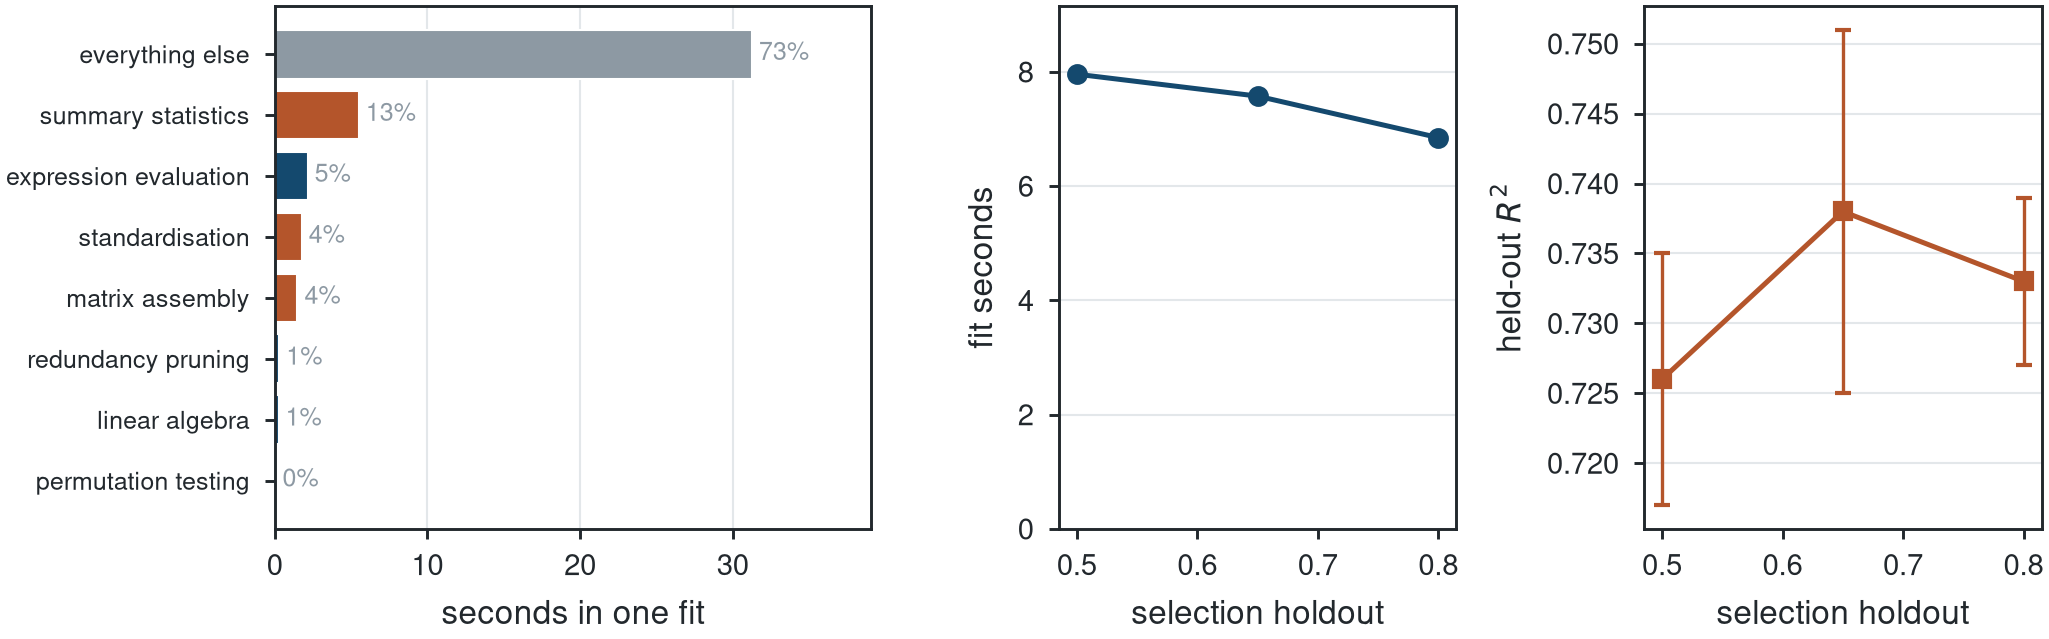

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(COL_DOUBLE, 2.3),
                         gridspec_kw={"width_ratios": [1.5, 1, 1]})

ax = axes[0]                                   # where a fit spends its seconds
d = profile_table.sort_values("seconds")
vectorisable = ("standardisation", "summary statistics", "matrix assembly")
colours = [WARN if c in vectorisable else NEUTRAL if c == "everything else" else ACCENT
           for c in d["cost centre"]]
ax.barh(d["cost centre"], d["seconds"], color=colours, edgecolor="white", linewidth=0.5)
for y, (v, s) in enumerate(zip(d["seconds"], d["share"])):
    ax.annotate(f" {s:.0f}%", (v, y), va="center", fontsize=6, color=NEUTRAL)
ax.set_xlabel("seconds in one fit"); ax.tick_params(axis="y", labelsize=6)
ax.set_xlim(0, d["seconds"].max() * 1.25)
ax.grid(True, axis="x", color=GRID, linewidth=0.5); ax.grid(False, axis="y")

ax = axes[1]                                   # cost against the size of the search half
ax.plot(holdout_summary.index, holdout_summary["seconds"], marker="o", color=ACCENT)
ax.set_xlabel("selection holdout"); ax.set_ylabel("fit seconds")
ax.set_ylim(0, holdout_summary["seconds"].max() * 1.15)

ax = axes[2]                                   # and what it costs in accuracy
ax.errorbar(holdout_summary.index, holdout_summary["r2_mean"],
            yerr=holdout_summary["r2_sd"], marker="s", color=WARN,
            capsize=2, linewidth=1.2, elinewidth=0.8)
ax.set_xlabel("selection holdout"); ax.set_ylabel("held-out $R^2$")
for ax in axes[1:]:
    ax.grid(True, axis="y", color=GRID, linewidth=0.5)

fig.tight_layout()
fig.savefig("figures/cost_profile.pdf"); fig.savefig("figures/cost_profile.png", dpi=300)
plt.show()

## Tables and figures

In [18]:
import glob, json, collections

rows = []
for f in glob.glob("results/highdim_*.json"):
    rows += json.load(open(f))
df = pd.DataFrame(rows)
if "error" not in df:
    df["error"] = None
ok = df[df["error"].isna()]
summary = (ok.groupby("method")
             .agg(mean_r2=("r2", "mean"), worst=("r2", "min"),
                  neg=("r2", lambda s: int((s < 0).sum())),
                  mean_features=("n_new", "mean"), mean_s=("seconds", "mean"))
             .sort_values("mean_r2", ascending=False).round(3))
errors = (df[df["error"].notna()].groupby("method")
            .error.apply(lambda s: collections.Counter(e.split(":")[0] for e in s)))
print(summary, "\n\nrecorded failures and budget hits:\n", errors, sep="")

piv = ok.pivot_table(index=["dataset", "split"], columns="method", values="r2")
print("\nper-dataset means:\n", piv.groupby("dataset").mean().round(3))

try:
    st = json.load(open("results/split_stability.json"))
    for k, v in st.items():
        print(f"{k:14s} R2 {v['r2_mean']:.3f}\u00b1{v['r2_std']:.3f} "
              f"Jaccard(eq) {v['jaccard_mean']:.2f} stable classes {len(v['stable_features'])}")
except FileNotFoundError:
    pass

                mean_r2  worst  neg  mean_features  mean_s
method                                                    
ridge_raw         0.708 -0.040    1            NaN   2.122
rf_raw            0.697  0.076    0            NaN   6.000
lgbm_raw          0.671 -0.447    3            NaN   3.004
beamfeat          0.671 -0.220    1         16.089  93.314
beamfeat_ridge    0.671 -0.235    1         16.089  86.900

recorded failures and budget hits:
Series([], Name: error, dtype: object)

per-dataset means:
 method             beamfeat  beamfeat_ridge  lgbm_raw  rf_raw  ridge_raw
dataset                                                                 
blogfeedback_p280     0.415           0.416     0.535   0.548      0.379
communities_p100      0.641           0.641     0.632   0.638      0.650
ct_slices_p384        0.687           0.687     0.981   0.981      0.852
eyedata_p200          0.416           0.412     0.031   0.340      0.479
geomusic_p117         0.805           0.805     0.739

In [21]:
!python make_figures.py

  wrote figures/highdim_comparison.pdf
  wrote figures/depth_ladder.pdf
  wrote figures/scalability.pdf
  wrote figures/selector_calibration.pdf
  wrote figures/split_stability.pdf
